In [1]:
!pip install torch torchvision matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Neu.zip to Neu.zip


In [5]:
import zipfile

with zipfile.ZipFile("Neu.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

In [6]:
import os
print(os.listdir("/content"))

['.config', 'Neu.zip', '.ipynb_checkpoints', 'NEU-DET', 'sample_data']


In [7]:
print(os.listdir("/content/NEU-DET/train/images"))

['scratches', 'crazing', 'patches', 'pitted_surface', 'inclusion', 'rolled-in_scale']


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
train_dir = "/content/NEU-DET/train/images"
val_dir = "/content/NEU-DET/validation/images"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print(num_classes)

6


In [10]:
def get_model(name):
    if name == "resnet34":
        model = models.resnet34(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "resnet50":
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "vgg16":
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif name == "alexnet":
        model = models.alexnet(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif name == "inception":
        model = models.inception_v3(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model.to(device)

In [11]:
def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc, val_acc = [], []
    train_loss, val_loss = [], []

    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc.append(correct / total)
        train_loss.append(running_loss / len(train_loader))

        model.eval()
        correct, total, running_loss = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc.append(correct / total)
        val_loss.append(running_loss / len(val_loader))

    return train_acc, val_acc, train_loss, val_loss

In [13]:
model_names = ["resnet34", "resnet50", "vgg16", "alexnet", "efficientnet"]

results = {}

for name in model_names:
    print("Training:", name)
    model = get_model(name)
    train_acc, val_acc, train_loss, val_loss = train_model(model, epochs=5)
    results[name] = {
        "train_acc": train_acc,
        "val_acc": val_acc,
        "train_loss": train_loss,
        "val_loss": val_loss
    }

Training: resnet34
Training: resnet50
Training: vgg16
Training: alexnet
Training: efficientnet


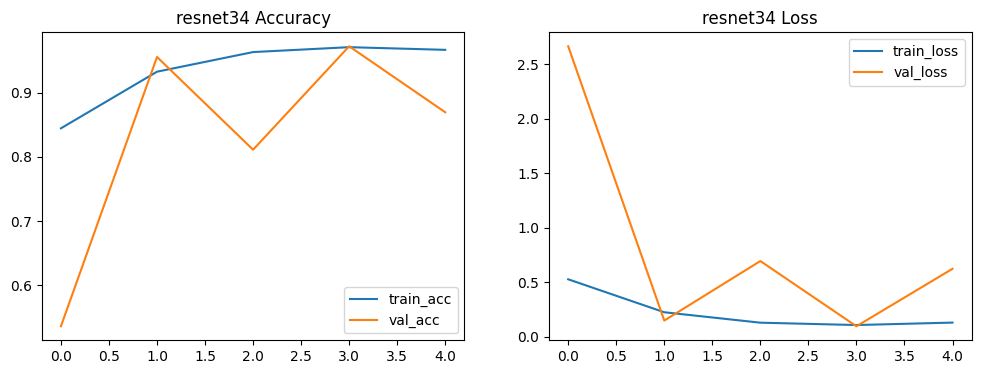

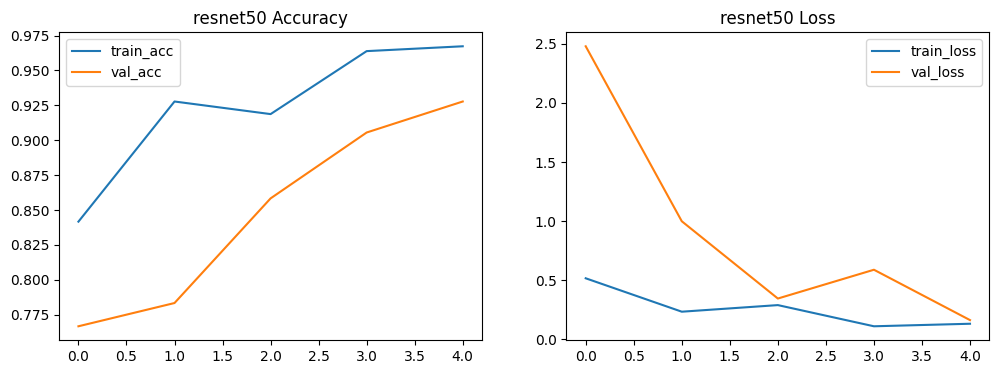

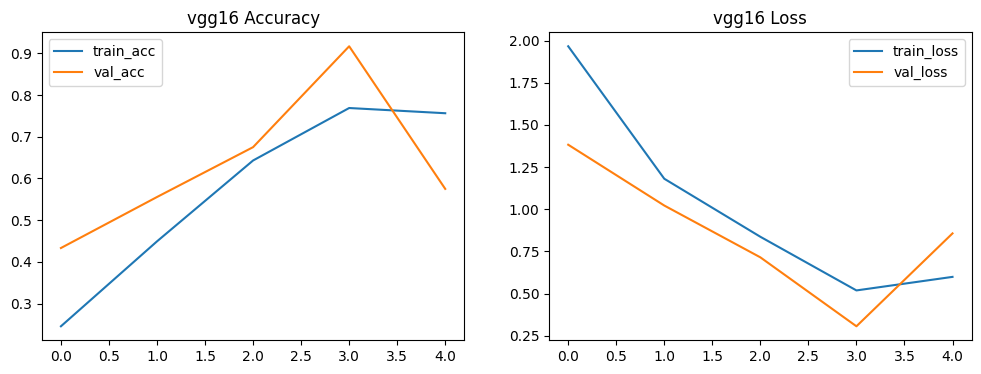

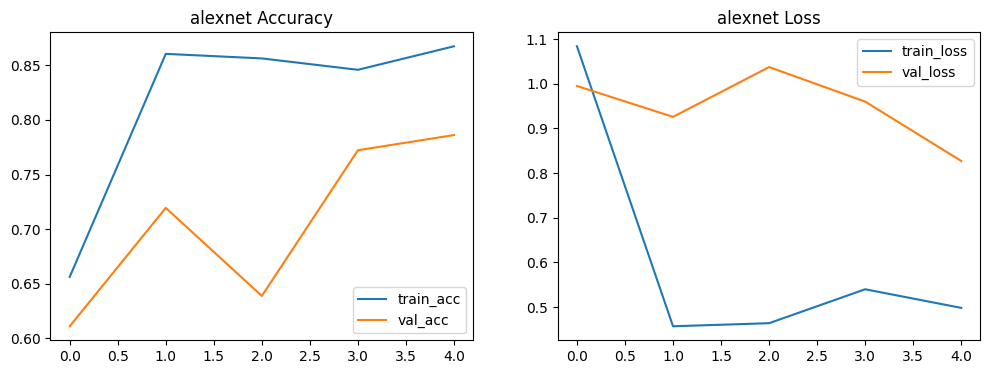

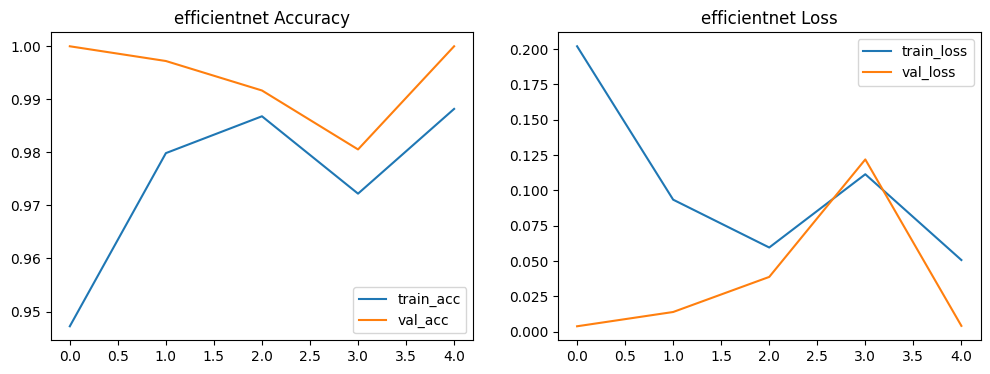

In [14]:
for name in results:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(results[name]["train_acc"], label="train_acc")
    plt.plot(results[name]["val_acc"], label="val_acc")
    plt.title(name + " Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(results[name]["train_loss"], label="train_loss")
    plt.plot(results[name]["val_loss"], label="val_loss")
    plt.title(name + " Loss")
    plt.legend()

    plt.show()

In [15]:
for name in results:
    print(name, "Final Val Accuracy:", results[name]["val_acc"][-1])

resnet34 Final Val Accuracy: 0.8694444444444445
resnet50 Final Val Accuracy: 0.9277777777777778
vgg16 Final Val Accuracy: 0.575
alexnet Final Val Accuracy: 0.7861111111111111
efficientnet Final Val Accuracy: 1.0
